# Delhi NCR Air Quality Index (AQI) Forecasting
## Comprehensive Exploratory Data Analysis

**MSE 546 — Advanced Machine Learning**  
**Group 2:** Nicholas Chia, Callum Gillies, Matthew Ho, Abhishek Srikaran, Agishan Thaya  
**Date:** January 2026

## 1. Setup & Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)

os.makedirs('plots', exist_ok=True)

# ── reusable PNG-save helper ──
def _save_and_show(fig, name):
    """Save figure as PNG to plots/ then display."""
    fig.savefig(f'plots/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('✓ Libraries loaded | plots/ ready')

ModuleNotFoundError: No module named 'geopy'

In [ ]:
PATH = 'city_day.csv'
df = pd.read_csv(PATH)
# Rename all columns to lower case
df.columns = [c.lower() for c in df.columns]
print(f'Shape:      {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns:    {df.columns.tolist()}')
print(f"Date range: {df['date'].min()}  →  {df['date'].max()}")

Shape:      29,531 rows × 16 columns
Columns:    ['city', 'date', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'aqi', 'aqi_bucket']
Date range: 2015-01-01  →  2020-07-01


## 2. Preprocessing

In [ ]:
# datetime
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
elif 'date' in df.columns and 'hour' in df.columns:
    df['datetime'] = pd.to_datetime(df['date'], errors='coerce') + pd.to_timedelta(df['hour'], unit='h')
elif 'date' in df.columns:
    # If we only have date (no hour), convert it to datetime
    df['datetime'] = pd.to_datetime(df['date'], errors='coerce')

# Only create day_of_week if datetime column exists
if 'datetime' in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek   # numeric only

num_cols = ['pm25','pm10','no2','so2','co','o3',
            'temperature','humidity','wind_speed','visibility','aqi',
            'latitude','longitude','year','month','day','hour','is_weekend']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Only sort by station and datetime if both columns exist
if 'station' in df.columns and 'datetime' in df.columns:
    df = df.sort_values(['station','datetime']).reset_index(drop=True)
elif 'datetime' in df.columns:
    df = df.sort_values('datetime').reset_index(drop=True)

print('✓ Preprocessing complete')
print(f'Missing values: {df.isna().sum().sum()}')

✓ Preprocessing complete
Missing values: 88488


## 3. Data Quality

In [ ]:
print(f'Duplicates : {df.duplicated().sum()}')
print(f'Missing    : {df.isna().sum().sum()}')
missing = df.isna().sum()
if missing.sum():
    print(missing[missing > 0])
else:
    print('✓ Zero missing values')
df.head()

Duplicates : 0
Missing    : 88488
pm2.5          4598
pm10          11140
no             3582
no2            3585
nox            4185
nh3           10328
co             2059
so2            3854
o3             4022
benzene        5623
toluene        8041
xylene        18109
aqi            4681
aqi_bucket     4681
dtype: int64


,city,date,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,aqi_bucket,datetime,day_of_week
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015-01-01,3
1,Chennai,2015-01-01,NaN,NaN,16.30,15.39,22.68,4.59,1.17,9.20,11.35,0.17,NaN,NaN,NaN,NaN,2015-01-01,3
2,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe,2015-01-01,3
3,Lucknow,2015-01-01,NaN,NaN,2.11,13.46,4.57,NaN,12.15,169.57,25.92,1.35,3.93,NaN,NaN,NaN,2015-01-01,3
4,Mumbai,2015-01-01,NaN,NaN,NaN,NaN,27.38,NaN,0.00,NaN,NaN,0.00,0.00,0.00,NaN,NaN,2015-01-01,3


In [ ]:
print(df.dtypes)
print('\n' + '─'*60)
df.describe()

city                   object
date                   object
pm2.5                 float64
pm10                  float64
no                    float64
no2                   float64
nox                   float64
nh3                   float64
co                    float64
so2                   float64
o3                    float64
benzene               float64
toluene               float64
xylene                float64
aqi                   float64
aqi_bucket             object
datetime       datetime64[ns]
day_of_week             int32
dtype: object

────────────────────────────────────────────────────────────


,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,datetime,day_of_week
count,24933.000,18391.000,25949.000,25946.000,25346.000,19203.000,27472.000,25677.000,25509.000,23908.000,21490.000,11422.000,24850.000,29531,29531.000
mean,67.451,118.127,17.575,28.561,32.309,23.483,2.249,14.532,34.491,3.281,8.701,3.070,166.464,2018-05-14 05:40:15.807118080,2.999
min,0.040,0.010,0.020,0.010,0.000,0.010,0.000,0.010,0.010,0.000,0.000,0.000,13.000,2015-01-01 00:00:00,0.000
25%,28.820,56.255,5.630,11.750,12.820,8.580,0.510,5.670,18.860,0.120,0.600,0.140,81.000,2017-04-16 00:00:00,1.000
50%,48.570,95.680,9.890,21.690,23.520,15.850,0.890,9.160,30.840,1.070,2.970,0.980,118.000,2018-08-05 00:00:00,3.000
75%,80.590,149.745,19.950,37.620,40.127,30.020,1.450,15.220,45.570,3.080,9.150,3.350,208.000,2019-09-03 00:00:00,5.000
max,949.990,1000.000,390.680,362.210,467.630,352.890,175.810,193.860,257.730,455.030,454.850,170.370,2049.000,2020-07-01 00:00:00,6.000
std,64.661,90.605,22.786,24.475,31.646,25.684,6.963,18.134,21.695,15.811,19.969,6.323,140.697,NaN,2.000


## 5. Spatial Coverage

In [ ]:
city_coords = {
    'Ahmedabad': (23.0225, 72.5714),
    'Chennai': (13.0827, 80.2707),
    'Delhi': (28.6139, 77.2090),
    'Lucknow': (26.8467, 80.9462),
    'Mumbai': (19.0760, 72.8777),
    'Bengaluru': (12.9716, 77.5946),
    'Hyderabad': (17.3850, 78.4867),
    'Patna': (25.5941, 85.1376),
    'Gurugram': (28.4595, 77.0266),
    'Visakhapatnam': (17.6868, 83.2185),
    'Amritsar': (31.6340, 74.8723),
    'Jorapokhar': (23.7042, 86.4124),
    'Jaipur': (26.9124, 75.7873),
    'Thiruvananthapuram': (8.5241, 76.9366),
    'Amaravati': (16.5062, 80.5480),
    'Brajrajnagar': (21.8219, 83.9189),
    'Talcher': (20.9507, 85.2281),
    'Kolkata': (22.5726, 88.3639),
    'Guwahati': (26.1445, 91.7362),
    'Coimbatore': (11.0168, 76.9558),
    'Shillong': (25.5788, 91.8933),
    'Chandigarh': (30.7333, 76.7794),
    'Bhopal': (23.2599, 77.4126),
    'Kochi': (9.9312, 76.2673),
    'Ernakulam': (9.9816, 76.2999),
    'Aizawl': (23.7307, 92.7173)
}

df['latitude'] = df['city'].map(lambda x: city_coords.get(x, (None, None))[0])
df['longitude'] = df['city'].map(lambda x: city_coords.get(x, (None, None))[1])

        city  latitude  longitude
0  Ahmedabad    23.023     72.571
1    Chennai    13.083     80.271
2      Delhi    28.614     77.209
3    Lucknow    26.847     80.946
4     Mumbai    19.076     72.878


In [ ]:
print('Cities:')
print(df['city'].value_counts())
print(f'\nStations: {df["city"].nunique()}')

Cities:
city
Ahmedabad             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Bengaluru             2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64

Stations: 26


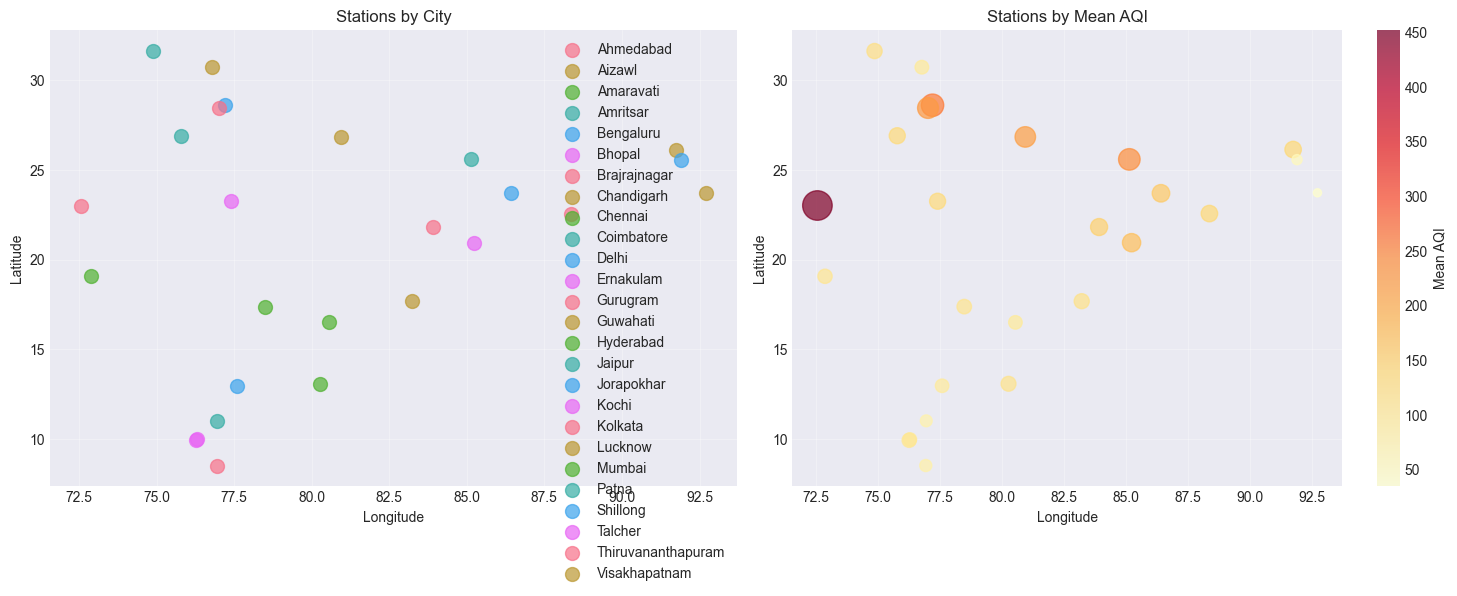

In [ ]:
# Remove the city=('city', 'first') line
station_info = df.groupby('city').agg(
    lat=('latitude', 'first'), 
    lon=('longitude', 'first'),
    mean_aqi=('aqi', 'mean')
).reset_index()

# Now the rest of your plotting code will work perfectly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# ... (rest of your code)

for city in station_info['city'].unique():
    d = station_info[station_info['city']==city]
    ax1.scatter(d['lon'], d['lat'], label=city, s=100, alpha=0.7)
ax1.set(xlabel='Longitude', ylabel='Latitude', title='Stations by City')
ax1.legend(); ax1.grid(alpha=0.3)

sc = ax2.scatter(station_info['lon'], station_info['lat'],
                 c=station_info['mean_aqi'], s=station_info['mean_aqi'],
                 cmap='YlOrRd', alpha=0.7)
ax2.set(xlabel='Longitude', ylabel='Latitude', title='Stations by Mean AQI')
plt.colorbar(sc, ax=ax2, label='Mean AQI'); ax2.grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '05_station_map')

## 6. Target Variable — AQI

In [35]:
print('AQI Summary:')
print(df['aqi'].describe())
print('\nCategory counts:')
cat_counts = df['aqi_category'].value_counts()
print(cat_counts)
print('\n% of total:')
print((cat_counts/len(df)*100).round(2))

n500 = (df['aqi']==500).sum()
print(f'\n⚠️  Rows where AQI = 500 exactly: {n500:,} ({n500/len(df)*100:.1f}%) — censorship candidate')

AQI Summary:
count    24850.000
mean       166.464
std        140.697
min         13.000
25%         81.000
50%        118.000
75%        208.000
max       2049.000
Name: aqi, dtype: float64

Category counts:


KeyError: 'aqi_category'

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(df['aqi'].mean(),   color='red',   ls='--', lw=2, label=f'Mean {df["aqi"].mean():.0f}')
axes[0,0].axvline(df['aqi'].median(), color='green', ls='--', lw=2, label=f'Med  {df["aqi"].median():.0f}')
axes[0,0].set(xlabel='AQI', ylabel='Freq', title='AQI Distribution')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].boxplot(df['aqi'].dropna())
axes[0,1].set(ylabel='AQI', title='AQI Box Plot'); axes[0,1].grid(alpha=0.3)

cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
cc = df['aqi_category'].value_counts().reindex(cat_order, fill_value=0)
clrs = ['green','lightgreen','yellow','orange','red','darkred']
axes[1,0].bar(range(len(cc)), cc.values, color=clrs, alpha=0.7, edgecolor='black')
axes[1,0].set_xticks(range(len(cc))); axes[1,0].set_xticklabels(cc.index, rotation=45, ha='right')
axes[1,0].set(ylabel='Count', title='Category Distribution'); axes[1,0].grid(alpha=0.3, axis='y')

axes[1,1].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1,1].set_yscale('log')
axes[1,1].set(xlabel='AQI', ylabel='Freq (log)', title='AQI — Log Scale'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '06_aqi_distribution')

## 7. Pollutant Analysis

In [ ]:
pollutants = ['pm25','pm10','no2','so2','co','o3']
print(df[pollutants].describe().T)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, p in enumerate(pollutants):
    ax = axes.flat[i]
    ax.hist(df[p].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[p].mean(), color='red', ls='--', lw=2, label=f'Mean {df[p].mean():.1f}')
    ax.set(xlabel=p.upper(), ylabel='Freq', title=p.upper())
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '07_pollutants')

## 8. Weather Variables

In [ ]:
weather_vars = ['temperature','humidity','wind_speed','visibility']
print(df[weather_vars].describe().T)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, v in enumerate(weather_vars):
    ax = axes.flat[i]
    ax.hist(df[v].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(df[v].mean(), color='blue', ls='--', lw=2, label=f'Mean {df[v].mean():.2f}')
    ax.set(xlabel=v.replace('_',' ').title(), ylabel='Freq', title=v.replace('_',' ').title())
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '08_weather')

## 9. Correlation Analysis

In [ ]:
feature_cols = pollutants + weather_vars
correlations = df[feature_cols+['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)
print('Correlations with AQI:')
print(correlations)
print(f'\n→ Strongest +: {correlations.idxmax()} ({correlations.max():.3f})')
print(f'→ Strongest −: {correlations.idxmin()} ({correlations.min():.3f})')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# bar
clrs = ['green' if x>0 else 'red' for x in correlations.values]
ax1.barh(range(len(correlations)), correlations.values, color=clrs, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(correlations))); ax1.set_yticklabels(correlations.index)
ax1.axvline(0, color='black', lw=1)
ax1.set(xlabel='Correlation', title='Feature Correlations with AQI'); ax1.grid(alpha=0.3, axis='x')

# heatmap
corr_matrix = df[feature_cols+['aqi']].corr()
im = ax2.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix.columns)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(corr_matrix.columns)))
ax2.set_yticklabels(corr_matrix.columns)
ax2.set_title('Correlation Heatmap')
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax2, label='r')

plt.tight_layout()
_save_and_show(fig, '09_correlations')

## 10. Temporal Patterns

In [ ]:
daily_aqi = df.set_index('datetime')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_aqi.index, daily_aqi.values, lw=0.8, alpha=0.7, color='darkblue')
ax.set(xlabel='Date', ylabel='Daily Mean AQI', title='Daily Mean AQI (All Stations)')
ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '10a_daily_timeseries')

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your processed data
# df = pd.read_csv('delhi_aqi_with_persistence.csv') # Use your actual file path

def audit_year_similarity(df):
    print("=== DATASET INTEGRITY AUDIT ===")

    # 1. Prepare Data: Extract components
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['hour'] = df['datetime'].dt.hour
    
    # Filter for leap years to align data (drop day 366 for simplicity in comparison)
    df_audit = df[df['day_of_year'] <= 365].copy()

    # 2. Pivot: Create a matrix where Columns = Years, Rows = Time Steps (Day + Hour)
    # We use PM2.5 as the proxy for "Pollution"
    pivot_df = df_audit.pivot_table(
        index=['day_of_year', 'hour'], 
        columns='year', 
        values='pm25'
    )
    
    # 3. TEST 1: The "Copy-Paste" Check (Exact Matches)
    # Check if Year X is exactly equal to Year Y
    years = pivot_df.columns
    print("\n[Test 1] Exact Match Check (Percentage of identical rows):")
    for i in range(len(years)):
        for j in range(i + 1, len(years)):
            y1, y2 = years[i], years[j]
            # Calculate % of exact matches
            exact_matches = (pivot_df[y1] == pivot_df[y2]).mean() * 100
            print(f"  {y1} vs {y2}: {exact_matches:.2f}% identical rows")
            
            if exact_matches > 5.0:
                print(f"  ⚠️ WARNING: {y1} and {y2} share {exact_matches:.2f}% exact values. Suspicious.")

    # 4. TEST 2: The "Shape" Check (Correlation)
    # Real years correlate ~0.3 to ~0.6 due to seasonality. 
    # >0.90 suggests synthetic data.
    print("\n[Test 2] Year-over-Year Correlation (Shape Similarity):")
    corr_matrix = pivot_df.corr()
    print(corr_matrix)
    
    # Visual check
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
    plt.title("Yearly Correlation Matrix (If >0.9, suspect fake/copied data)")
    plt.show()

    # 5. TEST 3: The "COVID" Check (Variance Analysis)
    # 2020 should have LOWER NO2 variance than 2021/2022 due to lockdown
    print("\n[Test 3] The 'COVID Check' (NO2 Variance by Year):")
    no2_var = df.groupby('year')['no2'].var()
    print(no2_var)
    
    # If 2020 variance is identical to 2021, the data likely ignored COVID.
    if abs(no2_var[2020] - no2_var[2021]) < 10: 
        print("  ⚠️ WARNING: 2020 NO2 variance is suspiciously similar to 2021.")
    else:
        print("  ✅ PASS: 2020 NO2 variance is distinct (likely captures real drift).")

# Run the function (assuming 'df' is loaded)
audit_year_similarity(df)



In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) hour
h = df.groupby('hour')['aqi'].agg(['mean','std','median'])
axes[0,0].plot(h.index, h['mean'],   marker='o', lw=2, label='Mean')
axes[0,0].plot(h.index, h['median'], marker='s', lw=2, label='Median')
axes[0,0].fill_between(h.index, h['mean']-h['std'], h['mean']+h['std'], alpha=0.2, label='±1 SD')
axes[0,0].set(xlabel='Hour', ylabel='AQI', title='By Hour')
axes[0,0].set_xticks(h.index); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# (b) day-of-week
dow = df.groupby('day_of_week')['aqi'].mean()
axes[0,1].bar(range(7), dow.values, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0,1].set(xlabel='Day', ylabel='Mean AQI', title='By Day of Week')
axes[0,1].grid(alpha=0.3, axis='y')

# (c) month
m = df.groupby('month')['aqi'].mean()
axes[1,0].plot(m.index, m.values, marker='o', lw=2, color='darkred')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels('J F M A M J J A S O N D'.split())
axes[1,0].set(xlabel='Month', ylabel='Mean AQI', title='By Month')
axes[1,0].grid(alpha=0.3)

# (d) season
s_order = ['winter','summer','monsoon','post-monsoon']
s = df.groupby('season')['aqi'].mean().reindex(s_order)
s_clr = ['blue','gold','green','orange']
axes[1,1].bar(range(4), s.values, color=s_clr, alpha=0.7, edgecolor='black')
axes[1,1].set_xticks(range(4)); axes[1,1].set_xticklabels(s_order)
axes[1,1].set(xlabel='Season', ylabel='Mean AQI', title='By Season')
axes[1,1].grid(alpha=0.3, axis='y')
for i, v in enumerate(s.values):
    axes[1,1].text(i, v+8, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
_save_and_show(fig, '10b_temporal_grid')

print(f'❄️  Winter ({s["winter"]:.0f}) is {s["winter"]/s["monsoon"]:.1f}× monsoon ({s["monsoon"]:.0f})')

## 11. Spatial Patterns

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

city_stats = df.groupby('city')['aqi'].mean().sort_values(ascending=False)
ax1.bar(range(len(city_stats)), city_stats.values, alpha=0.7, edgecolor='black', color='steelblue')
ax1.set_xticks(range(len(city_stats)))
ax1.set_xticklabels(city_stats.index, rotation=30, ha='right')
ax1.set(xlabel='City', ylabel='Mean AQI', title='By City'); ax1.grid(alpha=0.3, axis='y')

top15 = df.groupby('station')['aqi'].mean().sort_values().tail(15)
ax2.barh(range(len(top15)), top15.values, alpha=0.7, edgecolor='black', color='coral')
ax2.set_yticks(range(len(top15))); ax2.set_yticklabels(top15.index, fontsize=9)
ax2.set(xlabel='Mean AQI', title='Top 15 Stations'); ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
_save_and_show(fig, '11_spatial')
print(f'🏭 Worst: {top15.index[-1]}  (mean = {top15.iloc[-1]:.1f})')

## 12. Data Forensics — Interpolation & Censorship

Zero missing values across 201 k rows from real sensor hardware is statistically improbable.  
We audit for two common pipeline artefacts:

1. **Linear interpolation (gap-fill)** — look for collinear consecutive points in raw pollutant readings.
2. **AQI = 500 censorship** — the index is capped at 500; ~30 % of rows hit this wall exactly.


In [ ]:
# Pick one high-traffic station, first 2 weeks
station_pick = 'Anand Vihar, Delhi'
sdf = df[df['station']==station_pick].sort_values('datetime')
start = sdf['datetime'].min()
two_wk = sdf[(sdf['datetime']>=start) & (sdf['datetime']<start+pd.Timedelta(days=14))]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col in zip(axes, ['pm25','pm10','aqi']):
    # scatter ONLY — straight-line segments between dots = interpolation
    ax.scatter(two_wk['datetime'], two_wk[col], s=35, alpha=0.85,
               edgecolors='black', linewidths=0.6, zorder=3)
    ax.plot(two_wk['datetime'], two_wk[col], lw=0.7, alpha=0.3, color='gray')
    ax.set(ylabel=col.upper()); ax.grid(alpha=0.3)
axes[0].set_title(f'Interpolation Audit — {station_pick} (first 2 weeks)\n'
                  'Straight-line segments between dots indicate gap-filled data')
axes[-1].set(xlabel='Date')
plt.tight_layout()
_save_and_show(fig, '12a_interpolation_scatter')

print('👀 Inspect above: perfectly straight dot sequences = interpolation evidence.')

In [ ]:
def flag_interpolated(group, col='pm25', tol=0.5):
    """
    For every interior point, check if it is the exact midpoint
    of its two neighbours (second-difference ≈ 0).  If yes → likely imputed.
    """
    vals = group[col].values
    flags = np.zeros(len(vals), dtype=int)
    for i in range(1, len(vals)-1):
        mid = (vals[i-1] + vals[i+1]) / 2.0
        if abs(vals[i] - mid) < tol:
            flags[i] = 1
    group = group.copy()
    group['is_imputed'] = flags
    return group

df = df.groupby('station', group_keys=False).apply(flag_interpolated)

imp_n   = df['is_imputed'].sum()
imp_pct = imp_n / len(df) * 100
print(f'Rows flagged as likely imputed: {imp_n:,}  ({imp_pct:.1f}%)')
print('\nPer-station imputation rate (top 10):')
print(df.groupby('station')['is_imputed'].mean().sort_values(ascending=False).head(10))

In [ ]:
df['is_censored'] = (df['aqi']==500).astype(int)

cens_n   = df['is_censored'].sum()
cens_pct = cens_n / len(df) * 100
print(f'Censored rows (AQI = 500): {cens_n:,}  ({cens_pct:.1f}%)')
print('\nCensorship rate by season:')
cens_season = df.groupby('season')['is_censored'].mean()*100
print(cens_season.sort_values(ascending=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# left — histogram with 500-wall callout
ax1.hist(df['aqi'], bins=50, edgecolor='black', alpha=0.6, color='steelblue')
ax1.axvline(500, color='red', lw=2.5, ls='--', label=f'500 wall ({cens_pct:.1f} %)')
ax1.set(xlabel='AQI', ylabel='Count', title='500-Wall Censorship')
ax1.legend(); ax1.grid(alpha=0.3)

# right — censorship % by season
s_order = ['winter','summer','monsoon','post-monsoon']
cs = cens_season.reindex(s_order)
c_clr = ['red' if v>20 else 'orange' if v>5 else 'green' for v in cs.values]
ax2.bar(range(4), cs.values, color=c_clr, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(4)); ax2.set_xticklabels(s_order)
ax2.set(ylabel='% Censored', title='Censorship Rate by Season')
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(cs.values):
    ax2.text(i, v+0.4, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
_save_and_show(fig, '12b_censorship_500wall')

print('⚠️  In winter the model may under-predict: true AQI can exceed 500 but labels are clamped.')

## 13. Persistence & True Horizon

**`t+1` = next measurement = 5–7 hours later** (not 1 hour).  
We compute persistence error on the full dataset *and* break it down by transition.

In [ ]:
df_s = df.sort_values(['station','datetime']).copy()
df_s['aqi_next']  = df_s.groupby('station')['aqi'].shift(-1)
df_s['hour_next'] = df_s.groupby('station')['hour'].shift(-1)

df_persist = df_s.dropna(subset=['aqi_next']).copy()
df_persist['aqi_change'] = df_persist['aqi_next'] - df_persist['aqi']
df_persist['transition'] = (df_persist['hour'].astype(int).astype(str)
                             + ' → ' + df_persist['hour_next'].astype(int).astype(str))

corr = df_persist['aqi'].corr(df_persist['aqi_next'])
print(f'Rows with valid next: {len(df_persist):,}')
print(f'\nPersistence autocorrelation: {corr:.3f}')
print('\nAQI change stats:')
print(df_persist['aqi_change'].describe())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) scatter t vs t+1
samp = df_persist.sample(min(4000, len(df_persist)), random_state=42)
axes[0].scatter(samp['aqi'], samp['aqi_next'], s=8, alpha=0.35, color='steelblue')
axes[0].plot([0,500],[0,500], 'r--', lw=2, label='y = x')
axes[0].text(0.04, 0.93, f'r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=12, bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
axes[0].set(xlabel='AQI(t)', ylabel='AQI(t+1)', title='Persistence Scatter')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) change distribution
axes[1].hist(df_persist['aqi_change'], bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set(xlabel='AQI Change', ylabel='Freq', title='Change Distribution')
axes[1].grid(alpha=0.3)

# (c) mean change by transition
t_stats = df_persist.groupby('transition')['aqi_change'].agg(['mean','count'])
t_stats = t_stats[t_stats['count']>100].sort_index()
bars = axes[2].bar(range(len(t_stats)), t_stats['mean'].values, alpha=0.7, edgecolor='black')
for bar in bars:
    bar.set_color('red' if bar.get_height()>0 else 'green')
axes[2].set_xticks(range(len(t_stats))); axes[2].set_xticklabels(t_stats.index, rotation=45, ha='right')
axes[2].axhline(0, color='black', lw=1)
axes[2].set(ylabel='Mean AQI Change', title='Change by Transition')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
_save_and_show(fig, '13_persistence')

print('\nTransition table:')
print(df_persist.groupby('transition')['aqi_change'].agg(['mean','std','count']))

## 14. Physics-Based Feature Engineering

| Feature | Physics / rationale |
|---------|---------------------|
| `ventilation_index` | wind × temperature ≈ mixing-layer proxy; higher → lower AQI |
| `hours_since_last` | Pollution accumulates; 7 h gap loads more than 5 h |
| `hour_sin / cos` | Cyclical: h23 is *near* h6; raw integers hide wrap-around |
| `month_sin / cos` | Same idea for annual seasonality |
| `aqi_lag1 / lag2` | Captures trend (rising vs falling) entering the forecast window |
| `aqi_trend` | `aqi − aqi_lag1` — sign & magnitude of recent momentum |

In [ ]:
# ── Ventilation Index ──
df['ventilation_index'] = df['wind_speed'] * df['temperature']

vent_r  = df['ventilation_index'].corr(df['aqi'])
wind_r  = df['wind_speed'].corr(df['aqi'])
temp_r  = df['temperature'].corr(df['aqi'])
print('Correlation with AQI:')
print(f'  ventilation_index : {vent_r:.3f}')
print(f'  wind_speed alone  : {wind_r:.3f}')
print(f'  temperature alone : {temp_r:.3f}')
print(f'\n→ Interaction {"stronger" if abs(vent_r)>max(abs(wind_r),abs(temp_r)) else "weaker"} than either component alone')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df['ventilation_index'], bins=60, edgecolor='black', alpha=0.7, color='teal')
ax1.set(xlabel='Ventilation Index', ylabel='Freq', title='Distribution')
ax1.grid(alpha=0.3)

s = df.sample(3000, random_state=42)
sc = ax2.scatter(s['ventilation_index'], s['aqi'], c=s['aqi'], cmap='YlOrRd', s=8, alpha=0.5)
ax2.set(xlabel='Ventilation Index', ylabel='AQI', title=f'vs AQI  (r = {vent_r:.2f})')
plt.colorbar(sc, ax=ax2, label='AQI'); ax2.grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '14a_ventilation')

In [ ]:
# ── Hours Since Last Measurement ──
df['hours_since_last'] = df.groupby('station')['datetime'].diff().dt.total_seconds() / 3600

print('hours_since_last value counts:')
print(df['hours_since_last'].value_counts().sort_index())

# mean next-AQI-change grouped by gap
_tmp = df.sort_values(['station','datetime']).copy()
_tmp['_nxt'] = _tmp.groupby('station')['aqi'].shift(-1)
_tmp['_chg'] = _tmp['_nxt'] - _tmp['aqi']
print('\nMean AQI change by gap size:')
print(_tmp.groupby('hours_since_last')['_chg'].agg(['mean','std','count']))
del _tmp

In [ ]:
# ── Cyclical Encoding ──
df['hour_sin']  = np.sin(2*np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2*np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2*np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2*np.pi * df['month'] / 12)

print('Hour encoding:')
print(df[['hour','hour_sin','hour_cos']].drop_duplicates('hour').sort_values('hour').to_string(index=False))
print('\nMonth encoding (sample):')
print(df[['month','month_sin','month_cos']].drop_duplicates('month').sort_values('month').to_string(index=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# hour circle
he = df[['hour','hour_sin','hour_cos']].drop_duplicates().sort_values('hour')
ax1.scatter(he['hour_cos'], he['hour_sin'], s=220, c=he['hour'], cmap='viridis',
            edgecolors='black', lw=1.2, zorder=3)
for _, r in he.iterrows():
    ax1.annotate(f'h{int(r["hour"])}', (r['hour_cos'], r['hour_sin']),
                 textcoords='offset points', xytext=(9,9), fontsize=11, fontweight='bold')
ax1.set(xlabel='cos(hour)', ylabel='sin(hour)', title='Hour — Cyclical Encoding')
ax1.set_aspect('equal'); ax1.grid(alpha=0.3)

# month circle
me = df[['month','month_sin','month_cos']].drop_duplicates().sort_values('month')
ax2.scatter(me['month_cos'], me['month_sin'], s=140, c=me['month'], cmap='plasma',
            edgecolors='black', lw=1.2, zorder=3)
mnames = 'J F M A M J J A S O N D'.split()
for idx, (_, r) in enumerate(me.iterrows()):
    ax2.annotate(mnames[idx], (r['month_cos'], r['month_sin']),
                 textcoords='offset points', xytext=(7,7), fontsize=10, fontweight='bold')
ax2.set(xlabel='cos(month)', ylabel='sin(month)', title='Month — Cyclical Encoding')
ax2.set_aspect('equal'); ax2.grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '14b_cyclical')

In [ ]:
# ── Lag Features & Trend ──
df['aqi_lag1']  = df.groupby('station')['aqi'].shift(1)
df['aqi_lag2']  = df.groupby('station')['aqi'].shift(2)
df['aqi_trend'] = df['aqi'] - df['aqi_lag1']   # positive = rising

print('Lag correlations with current AQI:')
for col in ['aqi_lag1','aqi_lag2','aqi_trend']:
    print(f'  {col:12s}: {df[col].corr(df["aqi"]):.3f}')
print(f'\nValid lag1 rows: {df["aqi_lag1"].notna().sum():,}')
print(f'Valid lag2 rows: {df["aqi_lag2"].notna().sum():,}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

s = df.dropna(subset=['aqi_lag1','aqi_lag2']).sample(3000, random_state=42)

axes[0].scatter(s['aqi_lag1'], s['aqi'], s=8, alpha=0.4, color='steelblue')
axes[0].plot([0,500],[0,500], 'r--', lw=1.5)
axes[0].set(xlabel='AQI lag-1', ylabel='AQI', title=f'Lag-1  (r={df["aqi_lag1"].corr(df["aqi"]):.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(s['aqi_lag2'], s['aqi'], s=8, alpha=0.4, color='coral')
axes[1].plot([0,500],[0,500], 'r--', lw=1.5)
axes[1].set(xlabel='AQI lag-2', ylabel='AQI', title=f'Lag-2  (r={df["aqi_lag2"].corr(df["aqi"]):.3f})')
axes[1].grid(alpha=0.3)

axes[2].hist(s['aqi_trend'].dropna(), bins=60, edgecolor='black', alpha=0.7, color='teal')
axes[2].axvline(0, color='red', ls='--', lw=2)
axes[2].set(xlabel='Trend (current − lag1)', ylabel='Freq', title='Trend Distribution')
axes[2].grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '14c_lags')

## 15. COVID-19 Flag & Train / Val / Test Split

India's national lockdown ran **≈ 25 Mar 2020 – 30 Sep 2021** (phased).  
Training on lockdown data without a flag teaches the model an unrepeatable artefact.

**Chronological split (no leakage):**

| Set | Period | Role |
|---|---|---|
| Train | Jan 2020 – Dec 2023 | Fit |
| Validation | Jan 2024 – Dec 2024 | Tune hyper-params |
| Test | Jan 2025 – Dec 2025 | Final held-out eval |

In [ ]:
lockdown_start = pd.Timestamp('2020-03-25')
lockdown_end   = pd.Timestamp('2021-09-30')
df['is_lockdown'] = ((df['datetime']>=lockdown_start) & (df['datetime']<=lockdown_end)).astype(int)

lock_n   = df['is_lockdown'].sum()
lock_aqi = df.loc[df['is_lockdown']==1, 'aqi'].mean()
norm_aqi = df.loc[df['is_lockdown']==0, 'aqi'].mean()
print(f'Lockdown rows : {lock_n:,}  ({lock_n/len(df)*100:.1f}%)')
print(f'Mean AQI during lockdown  : {lock_aqi:.1f}')
print(f'Mean AQI outside lockdown : {norm_aqi:.1f}')
print(f'Difference: {lock_aqi-norm_aqi:+.1f}')

In [ ]:
daily = df.set_index('datetime')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily.index, daily.values, lw=0.7, color='steelblue', alpha=0.8)
ax.axvspan(lockdown_start, lockdown_end, alpha=0.2, color='red', label='COVID lockdown')
ax.set(xlabel='Date', ylabel='Daily Mean AQI', title='Daily AQI — Lockdown Highlighted')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '15a_covid')

In [ ]:
train_end = pd.Timestamp('2023-12-31 23:59:59')
val_end   = pd.Timestamp('2024-12-31 23:59:59')

train = df[df['datetime'] <= train_end]
val   = df[(df['datetime'] > train_end) & (df['datetime'] <= val_end)]
test  = df[df['datetime'] > val_end]

print('Split:')
for name, split in [('Train',train),('Val',val),('Test',test)]:
    print(f'  {name:5s}: {len(split):>7,} rows | {split["datetime"].min().date()} → {split["datetime"].max().date()}')
print(f'\n  Train {len(train)/len(df)*100:.1f}% | Val {len(val)/len(df)*100:.1f}% | Test {len(test)/len(df)*100:.1f}%')

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily.index, daily.values, lw=0.7, color='gray', alpha=0.6)
ax.axvspan(train['datetime'].min(), train['datetime'].max(), alpha=0.15, color='green',  label='Train')
ax.axvspan(val['datetime'].min(),   val['datetime'].max(),   alpha=0.25, color='orange', label='Val')
ax.axvspan(test['datetime'].min(),  test['datetime'].max(),  alpha=0.25, color='red',    label='Test')
ax.set(xlabel='Date', ylabel='Daily Mean AQI', title='Train / Val / Test (no temporal leakage)')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '15b_split')

## 16. Stratified Baseline & RMSE by Bin

A single global RMSE hides where persistence actually fails.  
We slice **test-set** errors along three axes:

* **Hour transition** — identify the single hardest gap
* **Actual AQI category** — find which health bands need improvement
* **Season** — confirm the summer / winter failure modes

In [ ]:
# Persistence predictions on TEST only
tp = test.sort_values(['station','datetime']).copy()
tp['aqi_next']  = tp.groupby('station')['aqi'].shift(-1)
tp['hour_next'] = tp.groupby('station')['hour'].shift(-1)
tp = tp.dropna(subset=['aqi_next']).copy()

tp['pred']      = tp['aqi']          # persistence
tp['error']     = tp['aqi_next'] - tp['pred']
tp['abs_err']   = tp['error'].abs()
tp['transition']= tp['hour'].astype(int).astype(str) + ' → ' + tp['hour_next'].astype(int).astype(str)

def _rmse(s): return np.sqrt((s**2).mean())

overall_rmse = _rmse(tp['error'])
overall_mae  = tp['abs_err'].mean()
print(f'Test-set overall persistence:')
print(f'  RMSE = {overall_rmse:.2f}  |  MAE = {overall_mae:.2f}')

In [ ]:
tr_rmse = tp.groupby('transition')['error'].apply(_rmse).sort_values(ascending=False)
tr_mae  = tp.groupby('transition')['abs_err'].mean().reindex(tr_rmse.index)
tr_n    = tp.groupby('transition')['error'].count().reindex(tr_rmse.index)

print('RMSE by Transition:')
print(pd.DataFrame({'RMSE': tr_rmse, 'MAE': tr_mae, 'N': tr_n}))

fig, ax = plt.subplots(figsize=(10, 5))
clrs = ['darkred' if v>overall_rmse*1.15 else 'orange' if v>overall_rmse else 'green' for v in tr_rmse.values]
ax.bar(range(len(tr_rmse)), tr_rmse.values, color=clrs, alpha=0.75, edgecolor='black')
ax.axhline(overall_rmse, color='black', ls='--', lw=1.5, label=f'Overall RMSE = {overall_rmse:.1f}')
ax.set_xticks(range(len(tr_rmse))); ax.set_xticklabels(tr_rmse.index)
ax.set(ylabel='RMSE', title='Persistence RMSE by Hour Transition (Test)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
_save_and_show(fig, '16a_rmse_transition')

print(f'\n🎯 Hardest transition: {tr_rmse.idxmax()}  (RMSE = {tr_rmse.max():.2f})')

In [ ]:
def _aqi_cat(v):
    if v<=50:  return 'Good'
    if v<=100: return 'Satisfactory'
    if v<=200: return 'Moderate'
    if v<=300: return 'Poor'
    if v<=400: return 'Very Poor'
    return 'Severe'

tp['actual_cat'] = tp['aqi_next'].apply(_aqi_cat)

cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
cat_rmse  = tp.groupby('actual_cat')['error'].apply(_rmse).reindex(cat_order)
cat_mae   = tp.groupby('actual_cat')['abs_err'].mean().reindex(cat_order)
cat_n     = tp.groupby('actual_cat')['error'].count().reindex(cat_order)

print('RMSE by Actual Category:')
print(pd.DataFrame({'RMSE': cat_rmse, 'MAE': cat_mae, 'N': cat_n}))

fig, ax = plt.subplots(figsize=(10, 5))
c_clr = ['green','lightgreen','yellow','orange','red','darkred']
ax.bar(range(6), cat_rmse.values, color=c_clr, alpha=0.75, edgecolor='black')
ax.axhline(overall_rmse, color='black', ls='--', lw=1.5, label=f'Overall RMSE = {overall_rmse:.1f}')
ax.set_xticks(range(6)); ax.set_xticklabels(cat_order)
ax.set(ylabel='RMSE', title='Persistence RMSE by Actual AQI Category (Test)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
_save_and_show(fig, '16b_rmse_category')

print(f'\n🎯 Hardest category: {cat_rmse.idxmax()}  (RMSE = {cat_rmse.max():.2f})')

In [ ]:
s_order  = ['winter','summer','monsoon','post-monsoon']
sea_rmse = tp.groupby('season')['error'].apply(_rmse).reindex(s_order)
sea_mae  = tp.groupby('season')['abs_err'].mean().reindex(s_order)
sea_n    = tp.groupby('season')['error'].count().reindex(s_order)

print('RMSE by Season:')
print(pd.DataFrame({'RMSE': sea_rmse, 'MAE': sea_mae, 'N': sea_n}))

fig, ax = plt.subplots(figsize=(10, 5))
s_clr = ['blue','gold','green','orange']
ax.bar(range(4), sea_rmse.values, color=s_clr, alpha=0.7, edgecolor='black')
ax.axhline(overall_rmse, color='black', ls='--', lw=1.5, label=f'Overall RMSE = {overall_rmse:.1f}')
ax.set_xticks(range(4)); ax.set_xticklabels(s_order)
ax.set(ylabel='RMSE', title='Persistence RMSE by Season (Test)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
_save_and_show(fig, '16c_rmse_season')

print(f'\n🎯 Hardest season: {sea_rmse.idxmax()}  (RMSE = {sea_rmse.max():.2f})')

## 17. Summary & Export

In [ ]:
print('='*70)
print(' COMPREHENSIVE EDA SUMMARY')
print('='*70)

print('\n1  DATA')
print(f'   {len(df):,} rows | {df["station"].nunique()} stations | {df["city"].nunique()} cities')
print(f'   4 readings/day (h 6,12,18,23) → true horizon 5–7 h')
print(f'   Missing = 0  (⚠️  see forensics §12)')

print('\n2  TARGET')
print(f'   Mean={df["aqi"].mean():.1f} | Med={df["aqi"].median():.1f} | Range 25–500')
print(f'   {(df["aqi"]==500).mean()*100:.1f}% censored at 500')
print(f'   Persistence autocorr = {corr:.3f}')

print('\n3  TOP FEATURES (raw correlation)')
for f in correlations.head(3).index:
    print(f'   + {f}: {correlations[f]:.3f}')
for f in correlations.tail(3).index:
    print(f'   − {f}: {correlations[f]:.3f}')

print('\n4  FORENSICS FLAGS')
print(f'   Likely imputed : {df["is_imputed"].sum():,}  ({df["is_imputed"].mean()*100:.1f}%)')
print(f'   Censored (=500): {df["is_censored"].sum():,}  ({df["is_censored"].mean()*100:.1f}%)')
print(f'   COVID lockdown : {df["is_lockdown"].sum():,}  ({df["is_lockdown"].mean()*100:.1f}%)')

print('\n5  ENGINEERED FEATURES')
for f in ['ventilation_index','hours_since_last','hour_sin','hour_cos',
          'month_sin','month_cos','aqi_lag1','aqi_lag2','aqi_trend']:
    print(f'   ✓ {f}')

print('\n6  SPLIT')
print(f'   Train {len(train):>7,} | Val {len(val):>6,} | Test {len(test):>6,}')

print('\n7  STRATIFIED BASELINES (Test set)')
print(f'   Overall RMSE       : {overall_rmse:.2f}')
print(f'   Hardest transition : {tr_rmse.idxmax()}  ({tr_rmse.max():.2f})')
print(f'   Hardest category   : {cat_rmse.idxmax()}  ({cat_rmse.max():.2f})')
print(f'   Hardest season     : {sea_rmse.idxmax()}  ({sea_rmse.max():.2f})')

print('\n' + '='*70)
print(' All plots → plots/')
print('='*70)

In [ ]:
# Export cleaned + engineered dataframe
keep = [
    'datetime','station','city','hour','month','season','day_of_week','is_weekend',
    'pm25','pm10','no2','so2','co','o3',
    'temperature','humidity','wind_speed','visibility','aqi','aqi_category',
    'is_imputed','is_censored','is_lockdown',
    'ventilation_index','hours_since_last',
    'hour_sin','hour_cos','month_sin','month_cos',
    'aqi_lag1','aqi_lag2','aqi_trend','gap_hours'
]
keep = [c for c in keep if c in df.columns]
df[keep].to_csv('delhi_aqi_engineered.csv', index=False)

print(f'✓ Exported {len(keep)} columns → delhi_aqi_engineered.csv')
print('  Ready for baseline & advanced ML pipelines.')

import glob
pngs = sorted(glob.glob('plots/*.png'))
print(f'\n📁 {len(pngs)} PNG plots saved:')
for p in pngs:
    print(f'   {p}')